In [27]:
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
import json
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cuda


In [28]:
BASE_DATA = '/kaggle/input/datasets/zahrapriyono/research-methodology/Emotion Classification in E-Commerce/data/processed' if os.path.exists('/kaggle') else '../data/processed'
BASE_ARTIFACTS = '/kaggle/input/datasets/zahrapriyono/research-methodology/Emotion Classification in E-Commerce/data/processed' if os.path.exists('/kaggle') else '../data/processed'

train_path = f'{BASE_DATA}/train.csv'
val_path   = f'{BASE_DATA}/val.csv'
test_path  = f'{BASE_DATA}/test.csv'

LABEL_MAPPING_PATH  = f'{BASE_ARTIFACTS}/label_mapping.json'
CLASS_WEIGHTS_PATH  = f'{BASE_ARTIFACTS}/class_weights.json'

FASTTEXT_PATH = '/kaggle/input/notebooks/novyanhafizh/deep-learning-based-sentiment-analysis-bahasa/cc.id.300.bin'

MAX_SEQ_LEN    = 128
EMBEDDING_DIM  = 300
HIDDEN_DIM     = 128
NUM_LAYERS     = 2
DROPOUT        = 0.5
BATCH_SIZE     = 32
LEARNING_RATE  = 1e-3
NUM_EPOCHS     = 20
PATIENCE       = 5
MAX_VOCAB      = 30000
MIN_FREQ       = 2
PRED_OUT       = '/kaggle/working/bilstm_fasttext_predictions.csv'

In [29]:
df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

for df in [df_train, df_val, df_test]:
    df['text']  = df['text'].astype(str)
    df['label'] = df['label'].astype(int)

num_labels = df_train['label'].nunique()
print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
print(f"Jumlah kelas: {num_labels}")

Train: 4202, Val: 525, Test: 526
Jumlah kelas: 5


In [30]:
with open(LABEL_MAPPING_PATH) as f:
    label_map = json.load(f)

id2label    = {v: k for k, v in label_map.items()}
label2id    = label_map
label_names = [id2label[i] for i in range(num_labels)]
print("Label order:", label_names)

with open(CLASS_WEIGHTS_PATH) as f:
    class_weights_dict = json.load(f)

weights = [class_weights_dict[str(i)] for i in range(num_labels)]

weight_tensor = torch.tensor(
    weights, 
    dtype=torch.float
).to(device)

Label order: ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']


In [31]:
def build_vocab(texts, max_vocab=30000, min_freq=2):
    word_freq = {}
    for text in texts:
        for word in text.split():
            word_freq[word] = word_freq.get(word, 0) + 1
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in sorted(word_freq.items(), key=lambda x: -x[1]):
        if freq >= min_freq and len(vocab) < max_vocab:
            vocab[word] = len(vocab)
    return vocab

vocab      = build_vocab(list(df_train['text']), max_vocab=MAX_VOCAB, min_freq=MIN_FREQ)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 3800


In [32]:
def text_to_sequence(text, vocab, max_len):
    tokens = text.split()[:max_len]
    seq    = [vocab.get(w, vocab['<UNK>']) for w in tokens]
    seq   += [vocab['<PAD>']] * (max_len - len(seq))
    return seq[:max_len]

X_train = np.array([text_to_sequence(t, vocab, MAX_SEQ_LEN) for t in df_train['text']])
X_val   = np.array([text_to_sequence(t, vocab, MAX_SEQ_LEN) for t in df_val['text']])
X_test  = np.array([text_to_sequence(t, vocab, MAX_SEQ_LEN) for t in df_test['text']])

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (4202, 128), X_val: (525, 128), X_test: (526, 128)


In [33]:
embedding_matrix = np.random.randn(vocab_size, EMBEDDING_DIM).astype(np.float32) * 0.01
embedding_matrix[0] = 0

fasttext_loaded    = False
fasttext_match_pct = 0.0

if os.path.exists(FASTTEXT_PATH):
    try:
        import fasttext
        ft = fasttext.load_model(FASTTEXT_PATH)
        words_found = 0
        for word, idx in vocab.items():
            if idx < 2:
                continue
            embedding_matrix[idx] = ft.get_word_vector(word)
            words_found += 1
        fasttext_loaded    = True
        fasttext_match_pct = 100 * words_found / vocab_size
        print(f"FastText loaded. Words matched: {words_found}/{vocab_size} ({fasttext_match_pct:.1f}%)")
        del ft
        gc.collect()
    except Exception as e:
        print(f"FastText load failed: {e}")
        print("Falling back to trainable random embeddings.")
else:
    print(f"FastText model not found at: {FASTTEXT_PATH}")
    print("Falling back to trainable random embeddings.")
    print("NOTE: If embeddings are random, rename the model to 'BiLSTM' not 'BiLSTM+FastText'.")

print(f"FastText active: {fasttext_loaded}")

FastText loaded. Words matched: 3798/3800 (99.9%)
FastText active: True


In [34]:
class BiLSTMAttentionEmotion(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers,
                 num_classes, embedding_matrix, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix).float())
        self.embedding.weight.requires_grad = True

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2       = nn.Linear(hidden_dim, num_classes)
        self.relu      = nn.ReLU()

    def forward(self, x):
        embedded     = self.embedding(x)
        lstm_out, _  = self.lstm(embedded)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context      = (attn_weights * lstm_out).sum(dim=1)
        out = self.dropout(context)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        return self.fc2(out)


model = BiLSTMAttentionEmotion(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=num_labels,
    embedding_matrix=embedding_matrix,
    dropout=DROPOUT
)
model.to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 2,009,382


In [35]:
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_train), torch.LongTensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True, generator=g
)
val_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_val), torch.LongTensor(y_val)),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_test), torch.LongTensor(y_test)),
    batch_size=BATCH_SIZE, shuffle=False
)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [36]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss   = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(output.argmax(dim=1).cpu().numpy())
        all_labels.extend(target.cpu().numpy())
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    return total_loss / len(loader), acc


def evaluate(model, loader, criterion):
    from sklearn.metrics import f1_score, precision_score, recall_score
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            total_loss += criterion(output, target).item()
            all_preds.extend(output.argmax(dim=1).cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    return (
        total_loss / len(loader),
        acc,
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        precision_score(all_labels, all_preds, average='macro', zero_division=0),
        recall_score(all_labels, all_preds, average='macro', zero_division=0),
        all_preds,
        all_labels
    )

In [37]:
history = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1']}
best_val_f1      = 0
best_model_state = None
patience_counter = 0

print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Val F1':<10}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1, _, _, _, _ = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"{epoch:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:<12.4f} {val_f1:<10.4f}")

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f"  ✓ Best F1: {best_val_f1:.4f} (lr={current_lr:.2e})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
print(f"\nBest val F1: {best_val_f1:.4f}")

Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Val F1    
-----------------------------------------------------------------
1        1.4562       0.3415       1.1899       0.4076       0.2281    
  ✓ Best F1: 0.2281 (lr=1.00e-03)
2        1.1091       0.4089       1.1564       0.2648       0.1685    
3        1.0301       0.4089       1.1122       0.4914       0.3297    
  ✓ Best F1: 0.3297 (lr=1.00e-03)
4        0.9950       0.4481       1.1706       0.4190       0.3114    
5        0.9784       0.4617       1.1777       0.5162       0.3441    
  ✓ Best F1: 0.3441 (lr=1.00e-03)
6        0.9379       0.5326       1.1918       0.4686       0.3455    
  ✓ Best F1: 0.3455 (lr=1.00e-03)
7        0.8146       0.6366       1.1253       0.5295       0.4893    
  ✓ Best F1: 0.4893 (lr=5.00e-04)
8        0.6557       0.7182       1.1986       0.5676       0.5302    
  ✓ Best F1: 0.5302 (lr=5.00e-04)
9        0.5612       0.7646       1.4527       0.5790       0.5251    
10       0

In [38]:
test_loss, test_acc, test_f1, test_prec, test_rec, y_pred, y_true = evaluate(
    model, test_loader, criterion
)

print(f"Accuracy:        {test_acc:.4f}")
print(f"Macro F1:        {test_f1:.4f}")
print(f"Macro Precision: {test_prec:.4f}")
print(f"Macro Recall:    {test_rec:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

Accuracy:        0.5760
Macro F1:        0.5380
Macro Precision: 0.5503
Macro Recall:    0.5336

Classification Report:
              precision    recall  f1-score   support

       Anger     0.6250    0.4478    0.5217        67
        Fear     0.2841    0.2809    0.2825        89
       Happy     0.8024    0.7657    0.7836       175
        Love     0.5542    0.5974    0.5750        77
     Sadness     0.4857    0.5763    0.5271       118

    accuracy                         0.5760       526
   macro avg     0.5503    0.5336    0.5380       526
weighted avg     0.5847    0.5760    0.5774       526



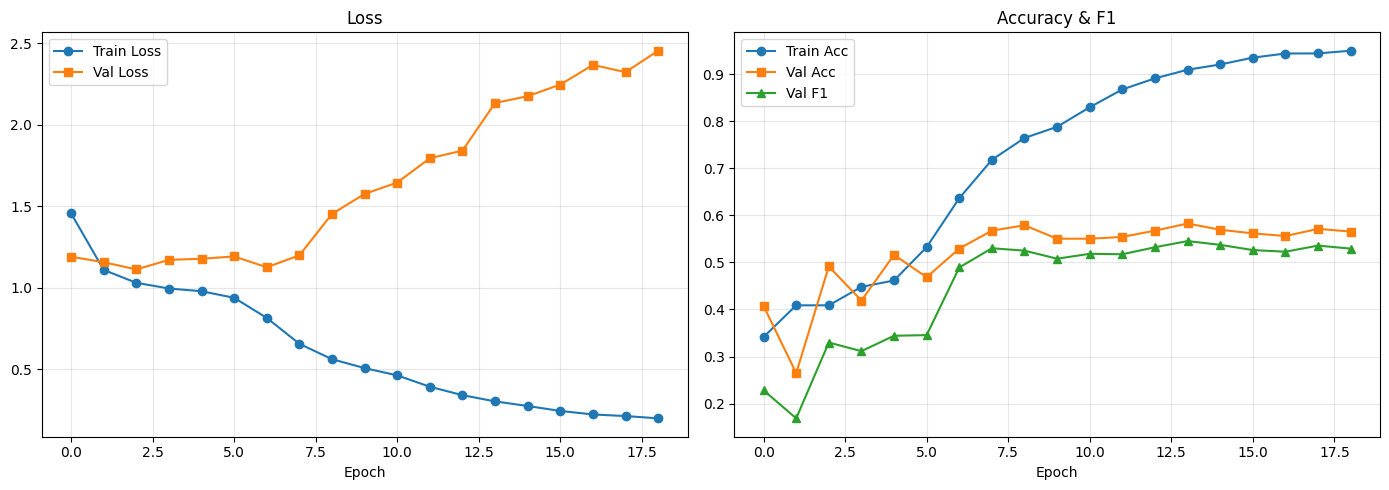

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'],   label='Val Acc',   marker='s')
axes[1].plot(history['val_f1'],    label='Val F1',    marker='^')
axes[1].set_title('Accuracy & F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
df_test_out = df_test.copy()
df_test_out['predicted_label']   = y_pred
df_test_out['predicted_emotion'] = [id2label[i] for i in y_pred]

model.eval()
all_probs = []
with torch.no_grad():
    for data, _ in test_loader:
        probs = F.softmax(model(data.to(device)), dim=1)
        all_probs.extend(probs.cpu().numpy())

probs_array = np.array(all_probs)
for i in range(num_labels):
    df_test_out[f'prob_{id2label[i]}'] = probs_array[:, i]

df_test_out.to_csv(PRED_OUT, index=False)
print(f"Prediction result is saved to: {PRED_OUT}")
print(f"FastText was active during this run: {fasttext_loaded}")
print(f"FastText vocab match rate: {fasttext_match_pct:.1f}%")   

metadata = {
    "fasttext_active":    fasttext_loaded,
    "fasttext_match_pct": round(fasttext_match_pct, 2),
    "vocab_size":         vocab_size,
    "seed":               SEED
}
with open('/kaggle/working/bilstm_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved to bilstm_metadata.json")

Prediction result is saved to: /kaggle/working/bilstm_fasttext_predictions.csv
FastText was active during this run: True
FastText vocab match rate: 99.9%
Metadata saved to bilstm_metadata.json
